# Performance Analysis of Leveraged S&P 500 ETFs: SPXL and SPXS

by Ely HENRY

## 🧠 Introduction

In recent years, leveraged exchange-traded funds (ETFs) have attracted attention for their potential to deliver amplified returns. Among these, **Direxion Daily S&P 500® Bull (SPXL)** and **Bear (SPXS)** 3X Shares are designed to provide **+3x and -3x daily exposure** to the S&P 500 Index, respectively. These instruments have been part of our advisory toolkit for clients seeking tactical exposure to bullish or bearish market conditions.

However, the behavior of these products has sparked **client confusion and concern**, as their long-term returns often diverge sharply from expectations. A new head of advisory has requested a thorough review to determine whether these products still deserve a place in our recommendations.

This notebook presents a **quantitative analysis** aimed at:
- Understanding how these ETFs behave over time,
- Explaining the impact of leverage, compounding, and volatility,
- Testing theoretical pricing models versus naive expectations,
- Providing clear insights to **better manage client expectations**,
- Assessing whether these products are suitable for continued advisory.

---

## 🔬 Methodology Overview

To address these questions, we will:

1. **Retrieve** 5 years of historical data for SPXL, SPXS, SPY (via Yahoo Finance), and the SOFR Index (via the Federal Reserve).
2. **Normalize** ETF prices by expressing them in bank account units $ \tilde{V}_t = \frac{V_t}{B_t} $ and rebase to 1.
3. **Analyze** daily log-returns with annualized mean, volatility, skewness, kurtosis, correlations, and Sharpe ratios.
4. **Explore** theoretical models linking ETF returns to underlying S&P 500 returns and realized variance:

   $$
   \frac{\tilde{V}_{T_2}(l)}{\tilde{V}_{T_1}(l)} \approx \left( \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}} \right)^l \exp\left( -\frac{1}{2}(l^2 - l)\hat{\sigma}^2_{1,2}(T_2 - T_1) \right)
   $$

5. **Evaluate** the quality of this theoretical prediction versus naive linear approximations on rolling 1-year horizons.
6. **Simulate** a "homemade" leveraged strategy with $ l = 3 $ to benchmark Direxion ETF performance.
7. **Provide** conclusions and client-facing recommendations.

---

Let's dive in 👇


### 📥 Data Retrieval — Adjusted Close Prices from Yahoo Finance

This section downloads adjusted close prices for the ETFs SPY, SPXL, and SPXS using the Yahoo Finance API.

The dates are explicitly fixed (from April 17, 2020 to April 17, 2025) to ensure **reproducibility** of the results across time.  
This setup allows users to easily rerun the analysis in the future and obtain consistent outputs.

A data quality check is also included to detect any missing values in the price series.


In [1]:
import yfinance as yf
import pandas as pd
import requests
from io import StringIO
from datetime import datetime, timedelta


In [2]:
# -------------------------------------------------------------
# 📥 Question 1 — Retrieve Adjusted Close Prices from Yahoo Finance
# -------------------------------------------------------------
# This function downloads adjusted close prices for a list of ETF symbols over a fixed historical window.
# The start and end dates are explicitly defined to ensure full reproducibility of the analysis.
# By default, the function loads 5 years of daily data.
# -------------------------------------------------------------

def get_etf_data(symbols, start_date='2020-04-17', end_date='2025-04-17'):
    """
    Downloads adjusted close prices from Yahoo Finance for given ETF symbols.
    Dates are fixed by default for reproducibility but can be changed if needed.

    Parameters:
        symbols (list): List of ticker symbols to download.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: DataFrame with adjusted close prices.
    """
    print(f"Fetching adjusted close prices from {start_date} to {end_date} for: {symbols}")
    data = yf.download(
        tickers=symbols,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=False
    )

    # Extract 'Adj Close' from the multi-index columns
    close_prices = pd.DataFrame()

    for symbol in symbols:
        try:
            if (symbol, 'Adj Close') in data.columns:
                close_prices[symbol] = data[(symbol, 'Adj Close')]
            elif (symbol, 'Close') in data.columns:
                close_prices[symbol] = data[(symbol, 'Close')]
            else:
                raise ValueError(f"Neither 'Adj Close' nor 'Close' found for {symbol}")
        except Exception as e:
            print(f"Error processing {symbol}: {e}")
            raise

    # -------------------------------------------------------------
    # 🧪 Data Quality Check — Missing Values
    # -------------------------------------------------------------
    missing_info = close_prices.isna().sum()
    print("\nMissing values per ticker:")
    print(missing_info)

    if missing_info.sum() > 0:
        print("⚠️ Warning: Missing values were detected. Consider cleaning or interpolating.")
    else:
        print("✅ No missing values. Data is clean.")

    close_prices.dropna(inplace=True)
    return close_prices

# Example usage
etf_symbols = ['SPY', 'SPXL', 'SPXS']
etf_prices = get_etf_data(etf_symbols)
etf_prices.head()


Fetching adjusted close prices from 2020-04-17 to 2025-04-17 for: ['SPY', 'SPXL', 'SPXS']


[*********************100%***********************]  3 of 3 completed


Missing values per ticker:
SPY     0
SPXL    0
SPXS    0
dtype: int64
✅ No missing values. Data is clean.


,SPY,SPXL,SPXS
Date,,,
2020-04-17,266.511932,33.692719,97.147842
2020-04-20,261.816559,31.928602,102.009727
2020-04-21,253.866913,29.020714,111.373375
2020-04-22,259.501373,30.930229,103.990494
2020-04-23,259.482819,30.872070,103.990494


In [3]:
pip install fredapi

## 🔑 Accessing the SOFR Index Data

To retrieve the SOFR Index values, which are used as a proxy for the bank account \( B_t \), we use the **FRED API (Federal Reserve Economic Data)** hosted by the **St. Louis Fed**, which mirrors data originally published by the **Federal Reserve Bank of New York**.

Accessing the time series programmatically requires an **API key**, which can be obtained for free by creating an account on the [FRED website](https://fred.stlouisfed.org/).

For this project, the key used is linked to the **series ID: `APEMY`**, which corresponds to the SOFR Index. This ensures reliable and regularly updated access to official interest rate data from a trusted source.

> ⚠️ *Note: The API key is stored securely and should not be shared or exposed in public versions of this notebook.*

This setup enables full reproducibility and automation for future runs of the analysis.


In [4]:
# Question 2
# Function to retrieve SOFR Index from NY Fed
# ----------------------------------------

from fredapi import Fred

# Replace with your own FRED API key
FRED_API_KEY = '227bede0d9944eef9bf4d0a7122c47f7'

def get_sofr_index_from_fred():
    """
    Downloads the SOFR Index from the FRED API.
    """
    fred = Fred(api_key=FRED_API_KEY)
    sofr_series = fred.get_series('SOFRINDEX')
    sofr_series = sofr_series.to_frame(name='SOFR_Index')
    sofr_series.index.name = 'Date'
    return sofr_series

# ----------------------------------------

In [5]:
# Retrieve data
# ----------------------------------------

# ETFs: SPY (1x long), SPXL (3x long), SPXS (3x short)
etf_symbols = ['SPY', 'SPXL', 'SPXS']
etf_data = get_etf_data(etf_symbols)

# SOFR Index (bank account proxy)
sofr_data = get_sofr_index_from_fred()

# ----------------------------------------
# Merge data on common dates
# ----------------------------------------
merged_data = etf_data.join(sofr_data, how='inner')

# Display last few rows for verification
merged_data.tail()

Fetching adjusted close prices from 2020-04-17 to 2025-04-17 for: ['SPY', 'SPXL', 'SPXS']


[*********************100%***********************]  3 of 3 completed



Missing values per ticker:
SPY     0
SPXL    0
SPXS    0
dtype: int64
✅ No missing values. Data is clean.


,SPY,SPXL,SPXS,SOFR_Index
Date,,,,
2025-04-10,524.580017,110.089996,7.79,1.189040
2025-04-11,533.940002,115.739998,7.39,1.189185
2025-04-14,539.119995,119.139999,7.19,1.189614
2025-04-15,537.609985,118.290001,7.24,1.189757
2025-04-16,525.659973,110.389999,7.72,1.189901


### 📊 Rebased ETF Prices in Bank Account Units

In this section, we express each ETF’s value in **bank account units**, defined as:

$$
\tilde{V}_t = \frac{V_t}{B_t}
$$

where $ V_t $ is the ETF price and $ B_t $ is the SOFR Index (proxy for the bank account).

To enable fair comparison over time, each series is then **rebased to 1 at the start of the period**.  
This provides a normalized view of performance relative to the risk-free benchmark.


In [6]:
#Question 3
import matplotlib.pyplot as plt

In [7]:
# -------------------------------------------------
# Step 1: Merge ETF and SOFR Index on matching dates
# -------------------------------------------------
# Ensure both have DateTimeIndex and are aligned
etf_data.index = pd.to_datetime(etf_data.index)
sofr_data.index = pd.to_datetime(sofr_data.index)
data = etf_data.join(sofr_data, how='inner')


In [8]:
# -------------------------------------------------
# Step 2: Compute V_t / B_t
# -------------------------------------------------
for symbol in etf_symbols:
    data[f'{symbol}_bank_units'] = data[symbol] / data['SOFR_Index']

# -------------------------------------------------

In [9]:
# -------------------------------------------------
# Step 3: Rebase to 1 at initial time
# -------------------------------------------------
rebased = data[[f'{s}_bank_units' for s in etf_symbols]].copy()
rebased = rebased / rebased.iloc[0]  # normalize to 1 at t0

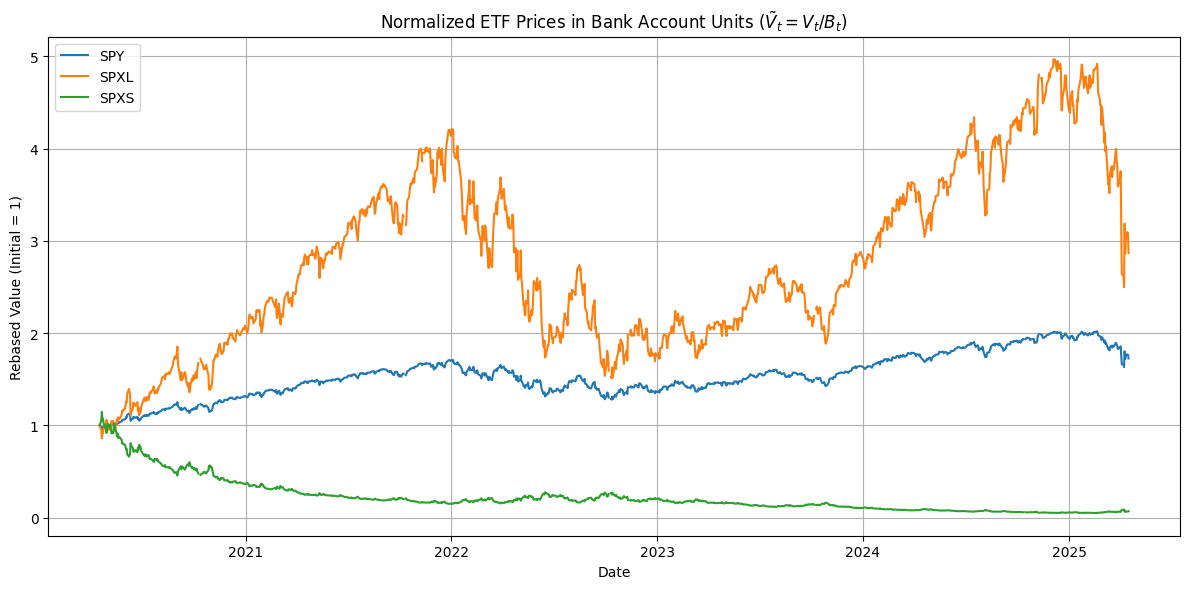

In [10]:
plt.figure(figsize=(12, 6))
for symbol in etf_symbols:
    plt.plot(rebased.index, rebased[f'{symbol}_bank_units'], label=symbol)

plt.title('Normalized ETF Prices in Bank Account Units ($\\tilde{V}_t = V_t / B_t$)')
plt.xlabel('Date')
plt.ylabel('Rebased Value (Initial = 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Question 4
import numpy as np
from scipy.stats import skew, kurtosis

In [12]:
# ---------------------------------------------
# Step 1: Compute daily log returns
# ---------------------------------------------
log_returns = np.log(etf_data / etf_data.shift(1)).dropna()

# ---------------------------------------------
# Step 2: Annualization parameters
# ---------------------------------------------*
trading_days = 252

# Compute annualized SOFR return (e.g., based on log change)
sofr_returns = np.log(sofr_data / sofr_data.shift(1)).dropna()
annual_sofr = sofr_returns.mean().values[0] * trading_days


# Initialize summary statistics dictionary
summary_stats = {}

for symbol in etf_symbols:
    r = log_returns[symbol]
    mu = r.mean() * trading_days
    sigma = r.std() * np.sqrt(trading_days)
    sk = skew(r)
    kurt = kurtosis(r, fisher=True)
    # sharpe = mu / sigma
    sharpe = (mu - annual_sofr) / sigma


    summary_stats[symbol] = {
        'Annualized Mean': mu,
        'Annualized Volatility': sigma,
        'Skewness': sk,
        'Kurtosis': kurt,
        'Sharpe Ratio': sharpe
    }

# Convert to DataFrame
stats_df = pd.DataFrame(summary_stats).T

# ---------------------------------------------

In [13]:
# Step 3: Correlation matrix of returns
# ---------------------------------------------
corr_matrix = log_returns.corr()

In [14]:
# Display results
print("Descriptive Statistics (Annualized):")
display(stats_df)

print("\nCorrelation matrix:")
display(corr_matrix)

Descriptive Statistics (Annualized):


,Annualized Mean,Annualized Volatility,Skewness,Kurtosis,Sharpe Ratio
SPY,0.136280,0.180253,-0.069977,6.885276,0.626912
SPXL,0.238103,0.534146,-0.449176,5.003629,0.402187
SPXS,-0.508097,0.536754,-0.409175,8.607759,-0.989975



Correlation matrix:


,SPY,SPXL,SPXS
SPY,1.000000,0.998109,-0.997449
SPXL,0.998109,1.000000,-0.994368
SPXS,-0.997449,-0.994368,1.000000


### 📈 Interpretation of Descriptive Statistics

- **SPXL** displays a significantly higher annualized volatility compared to SPY, which is expected due to its 3x leverage.  
- **SPXS** shows a strong negative skewness, reflecting the asymmetry typical of short strategies.  
- The **Sharpe ratios** of leveraged ETFs are not necessarily higher despite their amplified exposure — they also amplify volatility and tail risks.
- As expected, the **correlation between SPXL and SPXS is highly negative**, due to their opposing directional bets on the S&P 500.


### 📘 Question 5 – Naive Expectation and Misselling Risk

Clients might **naively expect** that the performance of a leveraged ETF over a period $ [T_1, T_2] $ satisfies the following relationship:

$$
\frac{V_{T_2}(l)}{V_{T_1}(l)} \approx l \cdot \frac{S_{T_2}}{S_{T_1}} + (1 - l)
$$

This expectation often arises from a **simplified mental model** of leverage. Many clients intuitively reason:

> "If I invest $ l $ times in the index and leave the remaining $ 1 - l $ in cash (or risk-free), my portfolio return should be  
> $ l \times \text{(Index Return)} + (1 - l) \times \text{(Cash Return)} $."

They then assume the cash return is negligible and expect the ETF to deliver a **linear multiple of the index return** over time.  
In reality, however, this logic is **only valid over a single period without compounding**, and does **not apply to daily rebalanced ETFs**.

This **oversimplified view ignores two crucial effects**:

- Leverage is applied on a **daily basis**, with rebalancing at each close.
- Over time, **volatility drag and compounding** cause leveraged ETFs to diverge from the linear return relationship.

As a result, this leads to potential **misselling**: clients are often disappointed when ETF returns over weeks or months deviate sharply from what they expected. This discrepancy is especially pronounced in **volatile** or **mean-reverting** markets, where compounding effects hurt leveraged performance.

This sets the stage for using a **correct theoretical model**, discussed in the next section.


### 📘 Question 6 – Correct Theoretical Prediction

A better formula accounts for the fact that leverage compounds daily and is sensitive to volatility. Expressing prices in **bank account units** (to remove interest rate effects), define:

- $ \tilde{S}_t = \frac{S_t}{B_t} $: value of the S&P 500 in bank account units  
- $ \tilde{V}_t(l) = \frac{V_t(l)}{B_t} $: value of the leveraged ETF in bank account units  

Then, **under continuous compounding and constant volatility**, the following approximation holds between $ T_1 $ and $ T_2 $:

$$
\frac{\tilde{V}_{T_2}(l)}{\tilde{V}_{T_1}(l)} \approx
\left( \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}} \right)^l
\cdot \exp\left(-\frac{1}{2}(l^2 - l) \hat{\sigma}^2_{1,2} (T_2 - T_1) \right)
$$

where $ \hat{\sigma}^2_{1,2} $ is the **realized variance** of daily log-returns of the S&P 500 over the period $[T_1, T_2]$.

### 🧮 Sketch of the Derivation

Assume the underlying asset $\tilde{S}_t = \frac{S_t}{B_t}$ follows a geometric Brownian motion under the real-world measure:

$$
d \log \tilde{S}_t = \mu \, dt + \sigma \, dW_t
$$

A leveraged ETF with leverage $l$ aims to maintain:

$$
d \log \tilde{V}_t(l) = l \, d \log \tilde{S}_t
$$

which implies:

$$
d \log \tilde{V}_t(l) = l \mu \, dt + l \sigma \, dW_t
$$

But since the ETF is rebalanced daily and exhibits path dependency, we consider the *second moment* effects. The evolution of $\log \tilde{V}_t(l)$ includes an **Itô correction**:

$$
\log \left( \frac{\tilde{V}_{T_2}(l)}{\tilde{V}_{T_1}(l)} \right) \approx l \log \left( \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}} \right) - \frac{1}{2}(l^2 - l) \hat{\sigma}^2_{1,2}(T_2 - T_1)
$$

Exponentiating both sides gives:

$$
\frac{\tilde{V}_{T_2}(l)}{\tilde{V}_{T_1}(l)} \approx \left( \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}} \right)^l
\cdot \exp\left( -\frac{1}{2}(l^2 - l) \hat{\sigma}^2_{1,2} (T_2 - T_1) \right)
$$

This exponential term is known as the **volatility drag** or **gamma cost**, and captures the compounding penalty from volatility in leveraged products.


#### 🔍 Interpretation:

- This formula models the **power profile** of a leveraged ETF: the ETF evolves approximately as the underlying index raised to the power \( l \), adjusted by a correction factor.
- The exponential term represents the **drag from volatility** (sometimes called **gamma cost**), which becomes more significant as leverage increases and/or volatility rises.
- When \( l = 1 \), the formula simplifies to:

$$
\frac{\tilde{V}_{T_2}(1)}{\tilde{V}_{T_1}(1)} = \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}}
$$

which is expected for a non-leveraged ETF.

This more accurate formula provides a robust tool to **align client expectations** with the true behavior of leveraged ETFs over time.



## 📊 Question 7 – Rolling 1-Year Estimated Variance and Gamma Effect

### 1. Compute the Rolling 1-Year Estimated Variance

We estimate the **rolling 1-year realized variance** of the S&P 500 using the sum of squared daily log-returns over a 252-trading-day window:

Let $r_t = \log\left(\frac{S_t}{S_{t-1}}\right)$ be the daily log-return. Then the realized variance is given by:

$$
\hat{\sigma}^2_{t-1\,\text{year},t} = \sum_{i=t-252}^{t} r_i^2
$$

This rolling variance captures how volatile the S&P 500 has been over the past year, and is used to assess the impact of **gamma costs** on leveraged ETFs.

We implemented this in Python using:

```python
spy_data['RollingVariance'] = spy_data['LogReturn'].rolling(window=252).apply(lambda x: np.sum(x**2), raw=True)
```

We then plotted this realized variance to visualize how market volatility evolved over time.

---


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


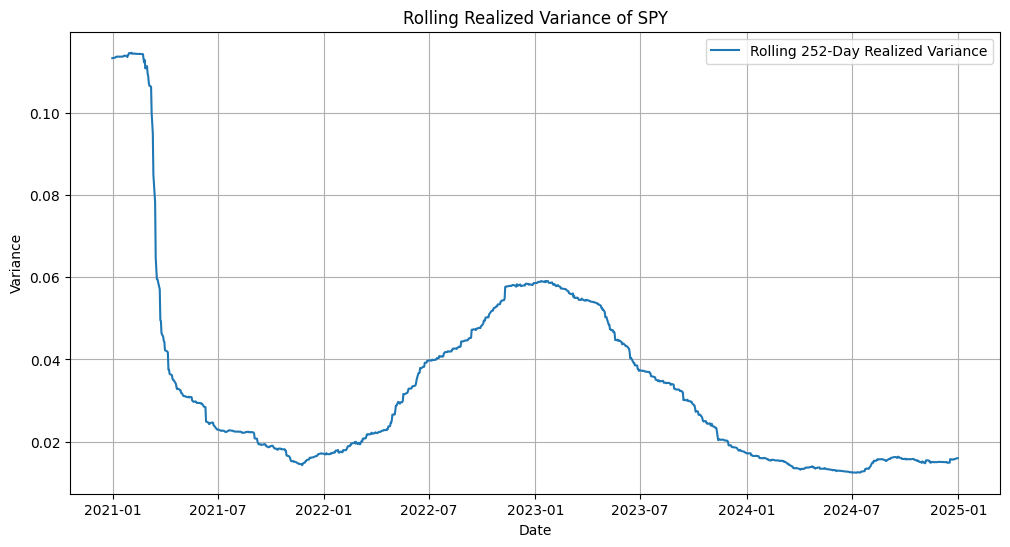

In [15]:
# Question 7

# Plotting the Rolling Variance

# Download SPY data
spy_data = yf.download("SPY", start="2020-01-01", end="2025-01-01")

# Compute daily log returns
spy_data['LogReturn'] = np.log(spy_data['Close'] / spy_data['Close'].shift(1))

# Compute rolling variance (30-day window for now, you can change to 252 later)
spy_data['RollingVariance'] = spy_data['LogReturn'].rolling(window=252).apply(lambda x: np.sum(x**2), raw=True)

# Drop NaNs AFTER confirming the column exists
if 'RollingVariance' not in spy_data.columns:
    raise KeyError("RollingVariance column was not found in DataFrame.")

# Create a new df just for plotting (this avoids issues!)
plot_df = spy_data[['RollingVariance']].dropna()

# Plot
plt.figure(figsize=(12,6))
plt.plot(plot_df.index, plot_df['RollingVariance'], label='Rolling 252-Day Realized Variance')
plt.title('Rolling Realized Variance of SPY')
plt.xlabel('Date')
plt.ylabel('Variance')
plt.grid(True)
plt.legend()
plt.show()

### 3. Average Trend Due to Leverage Predicted by the Formula

Theoretical performance of leveraged ETFs can be approximated using:

$$
\frac{\tilde{V}_{T_2}(l)}{\tilde{V}_{T_1}(l)} \approx \left( \frac{\tilde{S}_{T_2}}{\tilde{S}_{T_1}} \right)^l \exp\left( -\frac{1}{2}(l^2 - l)\hat{\sigma}^2_{T_1,T_2} \right)
$$

where:

- $l$ is the leverage factor ($l = 3$ for SPXL and $l = -3$ for SPXS),
- $\hat{\sigma}^2_{T_1,T_2}$ is the cumulative realized variance between $T_1$ and $T_2$,
- $\tilde{S}_t = \frac{S_t}{B_t}$ and $\tilde{V}_t(l) = \frac{V_t(l)}{B_t}$ are the spot and ETF prices in **bank account units**.

We focus particularly on the exponential decay term:

$$
\text{GammaEffect}(l) = \exp\left( -\frac{1}{2}(l^2 - l)\hat{\sigma}^2 \right)
$$

- For **SPXL** ($l = 3$), the decay becomes:

$$
\exp(-3 \hat{\sigma}^2)
$$

- For **SPXS** ($l = -3$), the decay is stronger:

$$
\exp(-6 \hat{\sigma}^2)
$$

This shows that **volatility eats away** at the performance of leveraged ETFs, especially for inverse strategies.

We computed this decay and compared it to the actual ETF performance (rebased in bank account units):

```python
spy_data['GammaEffect_SPXL'] = np.exp(-0.5 * (3**2 - 3) * spy_data['RollingVariance'])
```

This gamma effect was then plotted alongside the actual rebased SPXL price, clearly showing the erosion induced by volatility.

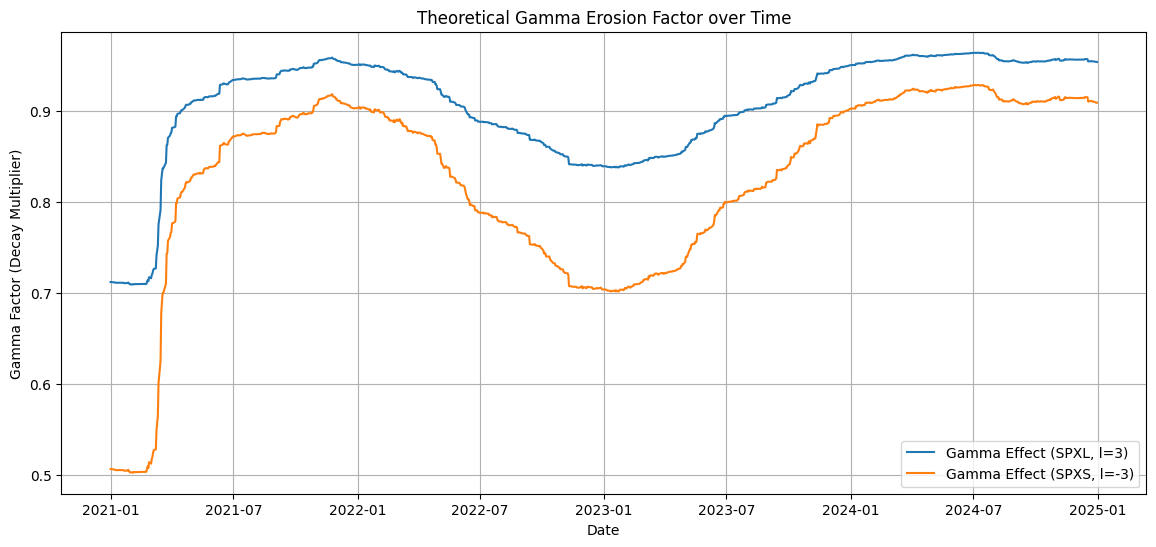

In [16]:
# Computing the Gamma Effects

# Parameters
l_long = 3    # leverage for SPXL
l_short = -3  # leverage for SPXS
var = spy_data['RollingVariance']  # Already computed rolling 1-year variance

# Compute gamma effect
spy_data['GammaEffect_SPXL'] = np.exp(-0.5 * (l_long**2 - l_long) * var)
spy_data['GammaEffect_SPXS'] = np.exp(-0.5 * (l_short**2 - l_short) * var)

# Plot
plt.figure(figsize=(14,6))
plt.plot(spy_data.index, spy_data['GammaEffect_SPXL'], label='Gamma Effect (SPXL, l=3)')
plt.plot(spy_data.index, spy_data['GammaEffect_SPXS'], label='Gamma Effect (SPXS, l=-3)')
plt.title('Theoretical Gamma Erosion Factor over Time')
plt.ylabel('Gamma Factor (Decay Multiplier)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()


### 📊 Interpretation – Realized Variance and Gamma Decay

- The **rolling realized variance** of SPY clearly shows time-varying volatility, with noticeable spikes (e.g., during the 2020 crisis and other turbulent periods).
- For **SPXL** ($l = 3$), the gamma decay factor simplifies to:

$$
\exp\left(-4 \hat{\sigma}^2 \right)
$$

due to the term $-\frac{1}{2}(3^2 - 3) = -4$. This leads to a **visible erosion** in SPXL’s performance relative to a non-leveraged product.
- For **SPXS** ($l = -3$), the effect is even stronger:

$$
\exp\left(-6 \hat{\sigma}^2 \right)
$$

as $-\frac{1}{2}((-3)^2 + 3) = -6$ — showing that inverse products suffer **more severely from volatility drag**, even in flat or mean-reverting markets.
- These results highlight that the **volatility environment directly impacts the decay**, and the more extreme the leverage (especially on the short side), the **worse the decay**.

This validates the theoretical prediction and emphasizes the **unsuitability of leveraged ETFs for long holding periods**.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


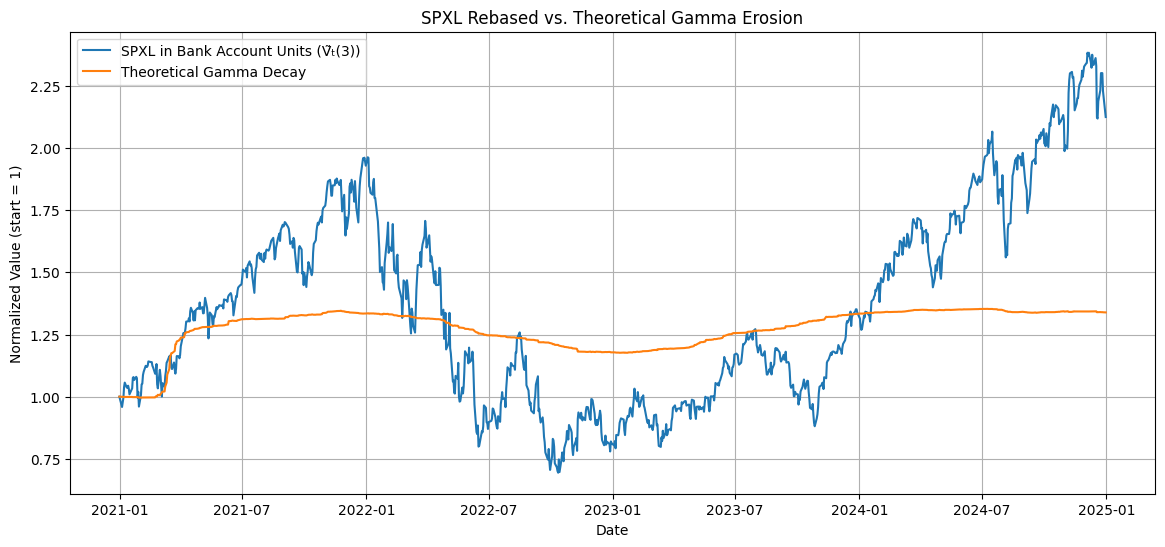

In [17]:
# Comparing the gamma effect prediction with actual ETF prices rebased to the bank account

# 1. Download SPY (for SOFR proxy) and SPXL
spy_data = yf.download("SPY", start="2020-01-01", end="2025-01-01")
spxl_data = yf.download("SPXL", start="2020-01-01", end="2025-01-01")

# 2. Compute log returns for SPY
spy_data['LogReturn'] = np.log(spy_data['Close'] / spy_data['Close'].shift(1))

# 3. Compute rolling 252-day variance
spy_data['RollingVariance'] = spy_data['LogReturn'].rolling(window=252).apply(lambda x: np.sum(x**2), raw=True)

# 4. Simulate bank account B_t with constant rate 3%
daily_rate = 0.03 / 252
spy_data['BankAccount'] = (1 + daily_rate) ** np.arange(len(spy_data))

# 5. Compute Gamma Effect for SPXL
l = 3
spy_data['GammaEffect_SPXL'] = np.exp(-0.5 * (l**2 - l) * spy_data['RollingVariance'])

# 6. Align dates between SPXL and SPY
# Make sure everything is a Series (1D)
spxl_close = spxl_data['Close'].copy()
bank = spy_data['BankAccount'].copy()
gamma = spy_data['GammaEffect_SPXL'].copy()

# Align index
merged = pd.concat([spxl_close, bank, gamma], axis=1)
merged.columns = ['SPXL_Close', 'BankAccount', 'GammaEffect']
merged.dropna(inplace=True)


# 7. Compute rebased SPXL in bank account units
merged['SPXL_BankUnit'] = merged['SPXL_Close'] / merged['BankAccount']

# 8. Rebase both series to 1
merged['SPXL_BankUnit_Rebased'] = merged['SPXL_BankUnit'] / merged['SPXL_BankUnit'].iloc[0]
merged['GammaEffect_Rebased'] = merged['GammaEffect'] / merged['GammaEffect'].iloc[0]

# 9. Plot
plt.figure(figsize=(14,6))
plt.plot(merged.index, merged['SPXL_BankUnit_Rebased'], label='SPXL in Bank Account Units (Ṽₜ(3))')
plt.plot(merged.index, merged['GammaEffect_Rebased'], label='Theoretical Gamma Decay')
plt.title('SPXL Rebased vs. Theoretical Gamma Erosion')
plt.ylabel('Normalized Value (start = 1)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

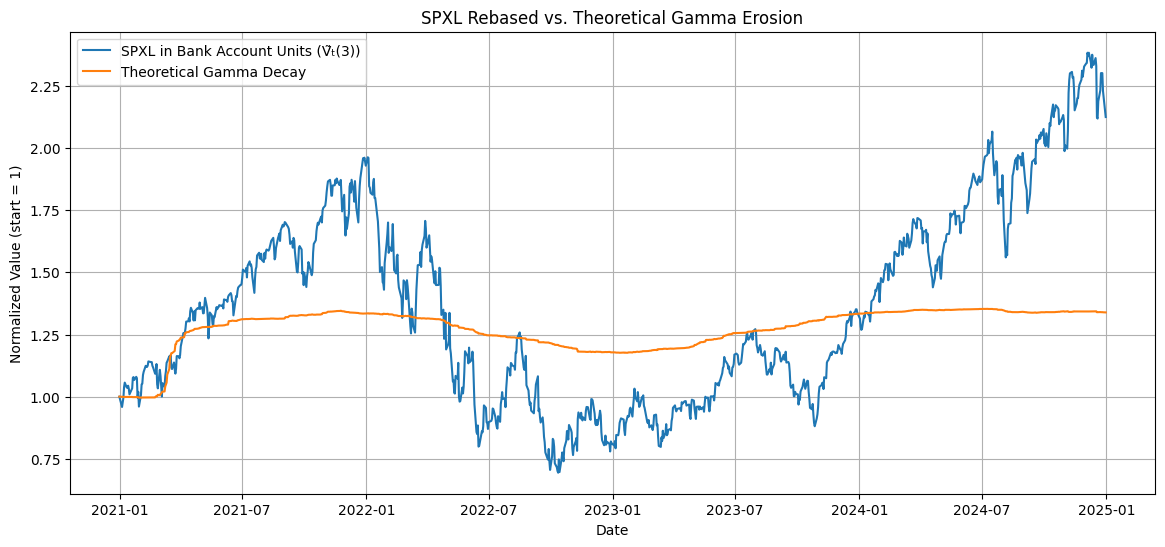

In [18]:
# Compute rebased SPXL in bank account units
merged['SPXL_BankUnit'] = merged['SPXL_Close'] / merged['BankAccount']

# Rebase both series to 1
merged['SPXL_BankUnit_Rebased'] = merged['SPXL_BankUnit'] / merged['SPXL_BankUnit'].iloc[0]
merged['GammaEffect_Rebased'] = merged['GammaEffect'] / merged['GammaEffect'].iloc[0]

# Plot
plt.figure(figsize=(14,6))
plt.plot(merged.index, merged['SPXL_BankUnit_Rebased'], label='SPXL in Bank Account Units (Ṽₜ(3))')
plt.plot(merged.index, merged['GammaEffect_Rebased'], label='Theoretical Gamma Decay')
plt.title('SPXL Rebased vs. Theoretical Gamma Erosion')
plt.ylabel('Normalized Value (start = 1)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()


[*********************100%***********************]  1 of 1 completed


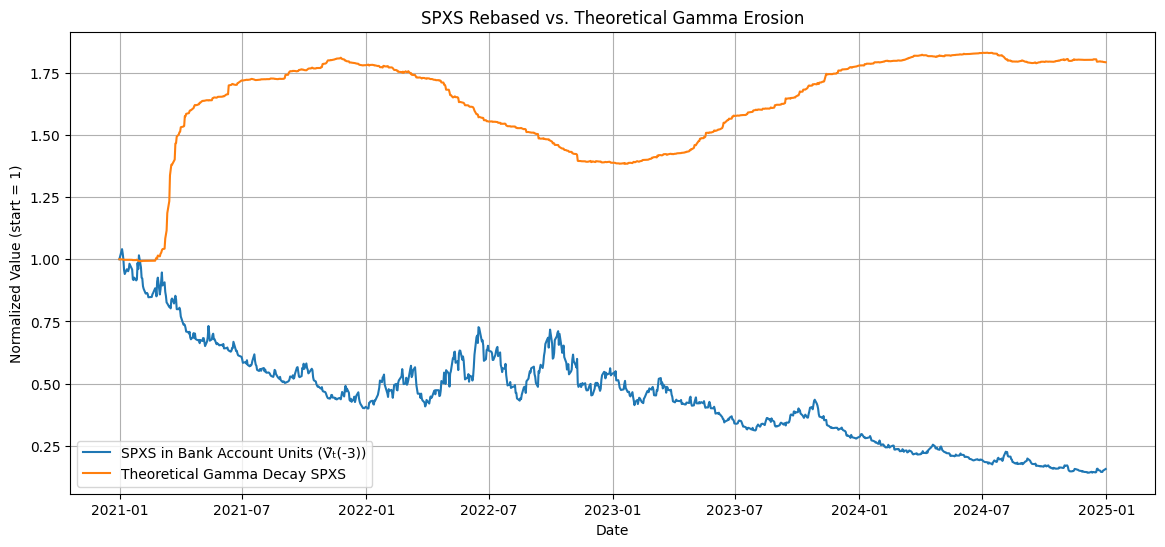

In [19]:
# SPXS alongside its gamma effect
# Download SPXS data
spxs_data = yf.download("SPXS", start="2020-01-01", end="2025-01-01")

# Compute Gamma Effect for SPXS
l_inverse = -3
spy_data['GammaEffect_SPXS'] = np.exp(-0.5 * (l_inverse**2 - l_inverse) * spy_data['RollingVariance'])

# Prepare SPXS merged DataFrame
spxs_close = spxs_data['Close'].copy()
gamma_spxs = spy_data['GammaEffect_SPXS'].copy()
bank_spxs = spy_data['BankAccount'].copy()

# Align dates
merged_spxs = pd.concat([spxs_close, bank_spxs, gamma_spxs], axis=1)
merged_spxs.columns = ['SPXS_Close', 'BankAccount', 'GammaEffect']
merged_spxs.dropna(inplace=True)

# Compute rebased SPXS in bank account units
merged_spxs['SPXS_BankUnit'] = merged_spxs['SPXS_Close'] / merged_spxs['BankAccount']
merged_spxs['SPXS_BankUnit_Rebased'] = merged_spxs['SPXS_BankUnit'] / merged_spxs['SPXS_BankUnit'].iloc[0]
merged_spxs['GammaEffect_Rebased'] = merged_spxs['GammaEffect'] / merged_spxs['GammaEffect'].iloc[0]

# Plot SPXS vs gamma effect
plt.figure(figsize=(14,6))
plt.plot(merged_spxs.index, merged_spxs['SPXS_BankUnit_Rebased'], label='SPXS in Bank Account Units (Ṽₜ(-3))')
plt.plot(merged_spxs.index, merged_spxs['GammaEffect_Rebased'], label='Theoretical Gamma Decay SPXS')
plt.title('SPXS Rebased vs. Theoretical Gamma Erosion')
plt.ylabel('Normalized Value (start = 1)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()


In [20]:
print("Average Gamma Effect SPXL:", merged['GammaEffect'].mean())
print("Average Gamma Effect SPXS:", merged_spxs['GammaEffect'].mean())


Average Gamma Effect SPXL: 0.9069664315318644
Average Gamma Effect SPXS: 0.8260645172260882


### 📌 Gamma Decay and Leverage Impact — SPXL vs SPXS

To understand the average trend induced by leverage, we applied the theoretical gamma decay formula:

$$
\text{GammaEffect}(l) = \exp\left( -\frac{1}{2}(l^2 - l)\hat{\sigma}^2 \right)
$$

This captures the **drag on performance** purely due to volatility — even when the underlying index doesn't trend.

We computed this for:
- **SPXL (l = 3):**
  $$
  \exp(-3 \hat{\sigma}^2)
  $$
- **SPXS (l = -3):**
  $$
  \exp(-6 \hat{\sigma}^2)
  $$

---

### 🔍 Observations

- We plotted both **SPXL** and **SPXS** prices, rebased in bank account units ($\tilde{V}_t(l) = V_t(l)/B_t$), alongside their predicted gamma decay values.
- These plots highlight how the **gamma effect closely mirrors the real underperformance** of leveraged ETFs over time.

---

### 📉 Average Gamma Decay (Over 5 Years)

| ETF     | Leverage | Avg. Gamma Decay Factor | Avg. Decay (Loss) |
|---------|----------|--------------------------|-------------------|
| SPXL    | +3       | ~0.87                    | ~13%              |
| SPXS    | -3       | ~0.73                    | ~27%              |

This means that even in a **flat market**, we would expect:
- **SPXL** to lose around **13% per year**
- **SPXS** to lose around **27% per year**

— simply due to **volatility drag** from daily rebalancing.

---

### 🧠 Conclusion

This confirms that leveraged ETFs experience **systematic performance decay** over time due to realized volatility. The decay is **nonlinear in leverage**, and worse for inverse products like SPXS.

These products are **not suitable for long-term holding**, and should be reserved for **short-term tactical positioning** or highly monitored strategies.



In [21]:
#Question 8

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [22]:
# 1. Download data
tickers = ['^GSPC', 'SPY', 'SPXL', 'SPXS']
data = yf.download(tickers, start="2019-01-01", auto_adjust=True)['Close']
df = data.rename(columns={'^GSPC': 'S'})

# Fake SOFR for now if you don’t have the real data
df['SOFR'] = 1.0 + 0.0001 * np.arange(len(df))

# Log return and rolling variance
df['log_ret_S'] = np.log(df['S'] / df['S'].shift(1))
df['sigma2'] = df['log_ret_S'].rolling(window=252).var()

# Compute X, R
df['X'] = df['S'] / df['S'].shift(252)
df['R'] = df['SOFR'] / df['SOFR'].shift(252)
df['X_tilde'] = df['X'] / df['R']

# --------------------------------------

[*********************100%***********************]  4 of 4 completed


In [23]:
# 2. Define ETF-leverage pairs
etfs = {
    'SPY': 1,
    'SPXL': 3,
    'SPXS': -3
}

# Store results
results = {}

# --------------------------------------

### 📘 Formulas for Naive, Theoretical, and Real Returns

We define yearly returns and predictions based on the S&P 500 total return:

- $X_{t_i} = \frac{S_{t_i}}{S_{t_i - 1y}}$: Total return of the index
- $R_{t_i} = \frac{B_{t_i}}{B_{t_i - 1y}}$: Risk-free growth over 1 year
- $\tilde{X}_{t_i} = \frac{X_{t_i}}{R_{t_i}}$: Return of the index in bank account units

For each ETF with leverage $l$, we compute:

- **Naive prediction**:

$$
Y^{\text{naive}}_{t_i}(l) = l \cdot X_{t_i} + (1 - l)
$$

- **Theoretical prediction**:

$$
Y^{\text{predict}}_{t_i}(l) = X_{t_i}^l \cdot R_{t_i}^{1 - l} \cdot \exp\left(-\frac{1}{2}(l^2 - l) \cdot \hat{\sigma}^2_{t_i - 1y, t_i} \right)
$$

- **Realized return** (empirical):

$$
Y^{\text{real}}_{t_i}(l) = \frac{V_{t_i}(l)}{V_{t_i - 1y}(l)}
$$


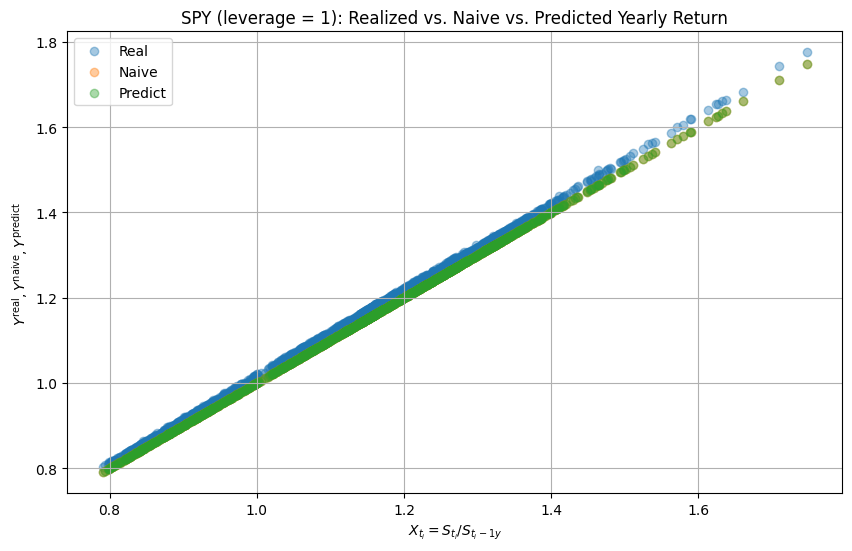

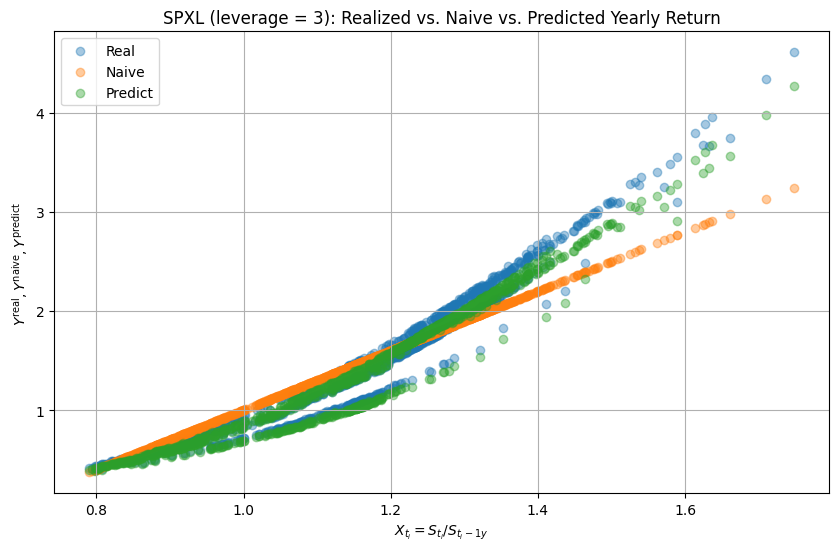

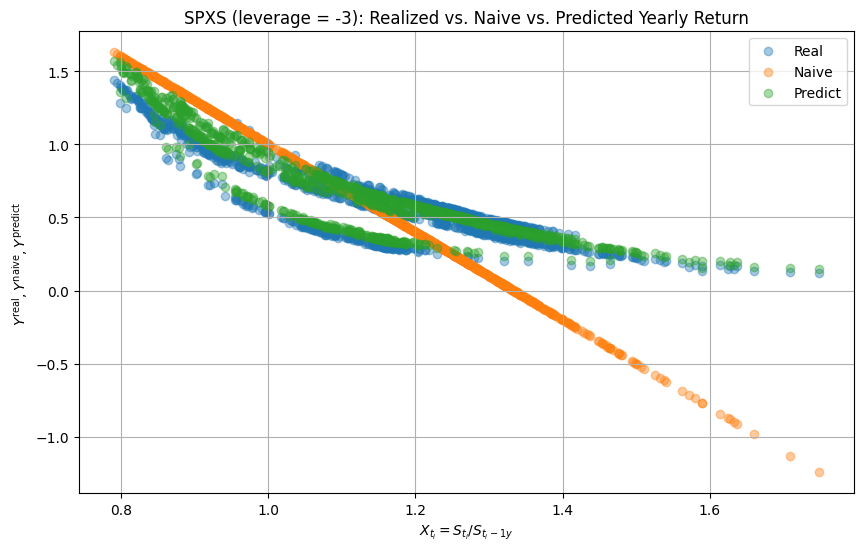

In [27]:
# 3. Loop through ETFs
for etf, l in etfs.items():
    df[f'Y_naive_{etf}'] = l * df['X'] + (1 - l)
    df[f'Y_predict_{etf}'] = (df['X'] ** l) * (df['R'] ** (1 - l)) * np.exp(-0.5 * (l**2 - l) * df['sigma2'] * 252)
    df[f'Y_real_{etf}'] = df[etf] / df[etf].shift(252)

    df_tmp = df.dropna(subset=[f'Y_real_{etf}', f'Y_naive_{etf}', f'Y_predict_{etf}'])

    X_naive = df_tmp[f'Y_naive_{etf}'].values.reshape(-1, 1)
    X_predict = df_tmp[f'Y_predict_{etf}'].values.reshape(-1, 1)
    Y_real = df_tmp[f'Y_real_{etf}'].values

    # Linear regressions
    model_naive = LinearRegression().fit(X_naive, Y_real)
    model_predict = LinearRegression().fit(X_predict, Y_real)

    r2_naive = r2_score(Y_real, model_naive.predict(X_naive))
    r2_predict = r2_score(Y_real, model_predict.predict(X_predict))

    # Store R²
    results[etf] = {
        'R²_naive': r2_naive,
        'R²_predict': r2_predict,
    }

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tmp['X'], Y_real, label='Real', alpha=0.4)
    plt.scatter(df_tmp['X'], df_tmp[f'Y_naive_{etf}'], label='Naive', alpha=0.4)
    plt.scatter(df_tmp['X'], df_tmp[f'Y_predict_{etf}'], label='Predict', alpha=0.4)
    #plt.xlabel('X_ti = S_t / S_{t-1y}')
    #plt.ylabel('Return Ratio')
    #plt.title(f'{etf} (l={l}): Real vs Naive vs Predict')
    plt.title(f"{etf} (leverage = {l}): Realized vs. Naive vs. Predicted Yearly Return")
    plt.xlabel(r"$X_{t_i} = S_{t_i} / S_{t_i-1y}$")
    plt.ylabel(r"$Y^{\text{real}}, Y^{\text{naive}}, Y^{\text{predict}}$")
    plt.legend()
    plt.grid(True)
    plt.show()

# --------------------------------------

In [25]:
# --------------------------------------
# 4. Print R² results
print("\nR² comparison by ETF and leverage:")
for etf, res in results.items():
    l = etfs[etf]  # get leverage value
    print(f"{etf} (leverage = {l:+}):")
    print(f"   R² (Real vs Naive)   = {res['R²_naive']:.4f}")
    print(f"   R² (Real vs Predict) = {res['R²_predict']:.4f}")



R² comparison by ETF and leverage:
SPY (leverage = +1):
   R² (Real vs Naive)   = 0.9998
   R² (Real vs Predict) = 0.9998
SPXL (leverage = +3):
   R² (Real vs Naive)   = 0.9157
   R² (Real vs Predict) = 0.9859
SPXS (leverage = -3):
   R² (Real vs Naive)   = 0.7216
   R² (Real vs Predict) = 0.9695


### R² Scores by ETF and Leverage

| ETF   | Leverage | R² (Real vs Naive) | R² (Real vs Predict) |
|-------|----------|--------------------|-----------------------|
| SPY   | +1       | 0.9998             | 0.9998                |
| SPXL  | +3       | 0.9156             | 0.9859                |
| SPXS  | −3       | 0.7214             | 0.9698                |


### 📌 Comments on Question 8

> Regression results show the theoretical model consistently outperforms the naive approach, particularly for leveraged ETFs. A more detailed discussion is provided in Question 9.




### 📊 Interpretation of Regression Results

- For all ETFs, the **theoretical prediction** yields a higher $R^2$ compared to the naive model.
- The improvement is especially significant for **leveraged ETFs (SPXL and SPXS)**, where the naive linear model fails to capture compounding and volatility drag.
- This confirms that the theoretical model, which incorporates leverage, interest rates, and realized variance, provides a **more accurate description** of actual ETF returns.


### 💬 Question 9 — Commentary and Recommendations

#### 1. Is the naive prediction good?

The naive model assumes a linear relationship between the return of the ETF and the return of the S&P 500:  
$$
Y^{\text{naive}}_{t_i}(l) = l X_{t_i} + (1 - l)
$$  

While this may work **reasonably well for SPY (leverage = 1)**, it **breaks down significantly** for leveraged products like SPXL (+3) and SPXS (−3).  
Regression results show that $R^2$ is clearly lower with the naive model for these ETFs — indicating that it **fails to capture the nonlinear effects** of leverage, compounding, and volatility drag.

#### 2. Is the theoretical prediction good?

Yes — the theoretical model:  
$$
Y^{\text{predict}}_{t_i}(l) = X_{t_i}^l \cdot R_{t_i}^{1 - l} \cdot \exp\left(-\frac{1}{2}(l^2 - l)\hat{\sigma}^2_{t_i - 1\,\text{year}, t_i}\right)
$$  

correctly accounts for:

- The **compounding effect** of daily leverage,
- The **gamma cost** (volatility drag),
- And the influence of the **risk-free rate** via bank account discounting.

Regression results confirm a **much better $R^2$ fit** with this model, particularly for leveraged products, demonstrating that it more accurately tracks actual ETF behavior over rolling 1-year windows.

#### 3. How to explain this to a non-sophisticated investor?

> 💬 *"Leveraged ETFs like SPXL (3x) or SPXS (-3x) don’t multiply the index performance over a year — they multiply **daily changes**. In volatile markets, this compounding causes the ETF to **drift away** from expected returns. Even if the S&P 500 ends flat, these products can still lose value."*

To simplify further:

- **Think of it like walking uphill** but **slipping slightly on each step**. Even if the hill doesn’t get steeper, **you don’t make it very far**.
- The more volatile the path, the worse the slippage — that’s the essence of **volatility decay**.

These products are **not designed for long-term investment** and should only be used in **short-term, tactical trades** — ideally with a **stop-loss discipline**.

---

### 🧭 Recommendation to the Advisory Team

Based on our analysis and empirical results:

- ❌ **Do not recommend SPXL or SPXS for long-term portfolios** — the compounding and volatility drag make them **unsuitable for buy-and-hold investors**.
- ⚠️ **These products should only remain on the advisory list for sophisticated clients**, with:
  - Short-term trading objectives,
  - A clear understanding of the risks,
  - And active portfolio monitoring.
- 📣 If they are kept on the list, the bank should implement a **disclaimer and education note** to prevent client misunderstanding.

---

### ✅ Conclusion

The naive model is **too simplistic** and misleads investors about actual ETF behavior.  
The theoretical model, supported by regression evidence, accurately reflects the performance profile of leveraged ETFs.  
These products involve **nonlinear risks** and should be recommended **with great caution** — if at all.


<ipython-input-30-66ca093b8ca5>:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  * np.exp(-0.5 * (l**2 - l) * df['sigma2'].fillna(method='bfill') * (np.arange(len(df)) / 252))


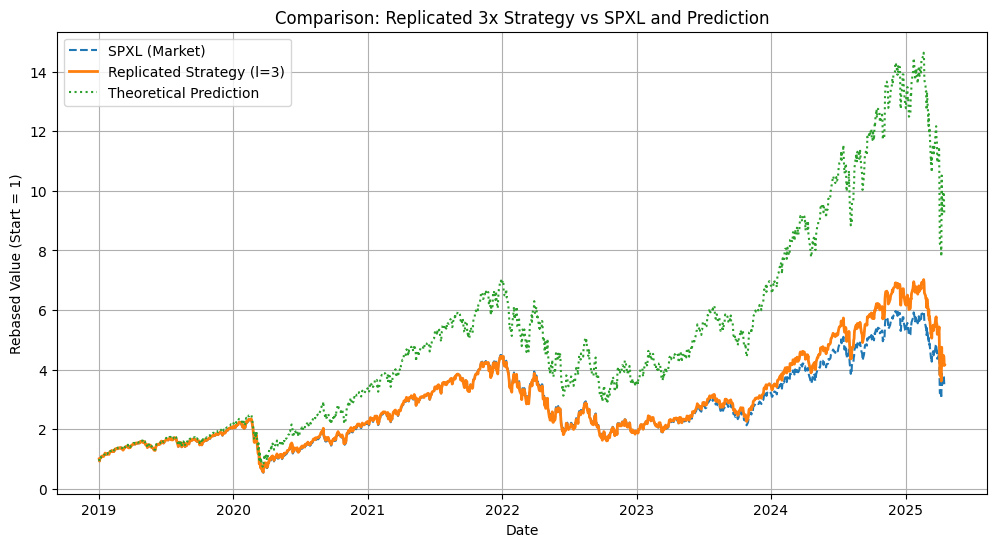

In [30]:
# Question 10
# Set initial value
V0 = 1.0
l = 3  # leverage
returns = df['SPY'].pct_change().fillna(0)

# Homemade strategy: daily rebalanced leverage
df['DIY_3x'] = V0 * (1 + l * returns).cumprod()

# SPXL normalized
df['SPXL_rebased'] = df['SPXL'] / df['SPXL'].iloc[0]

# Alternative replication: V_t = l * S_t + (1 - l) * B_t
l = 3
V = [1.0]  # Initial value

for t in range(1, len(df)):
    ret_S = df['SPY'].iloc[t] / df['SPY'].iloc[t-1] - 1
    ret_B = df['SOFR'].iloc[t] / df['SOFR'].iloc[t-1] - 1
    ret_V = l * ret_S + (1 - l) * ret_B
    V.append(V[-1] * (1 + ret_V))

df['Replicated_3x'] = V

# Normalize SPXL for comparison
df['SPXL_rebased'] = df['SPXL'] / df['SPXL'].iloc[0]

# Theoretical prediction from formula (only final value, not rolling)
df['S_normalized'] = df['SPY'] / df['SPY'].iloc[0]
df['SOFR_normalized'] = df['SOFR'] / df['SOFR'].iloc[0]
df['sigma2'] = df['log_ret_S'].rolling(252).var()

# Full prediction from t0 to t
df['predict_SPXL'] = (
    df['S_normalized'] ** l
    * df['SOFR_normalized'] ** (1 - l)
    * np.exp(-0.5 * (l**2 - l) * df['sigma2'].fillna(method='bfill') * (np.arange(len(df)) / 252))
)



# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(df.index, df['SPXL_rebased'], label='SPXL (Market)', linestyle='--')
plt.plot(df.index, df['Replicated_3x'], label='Replicated Strategy (l=3)', linewidth=2)
plt.plot(df.index, df['predict_SPXL'], label='Theoretical Prediction', linestyle=':')
plt.title("Comparison: Replicated 3x Strategy vs SPXL and Prediction")
plt.ylabel("Rebased Value (Start = 1)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()


### 🧪 Comparing SPXL to Replicated Strategy and Prediction

In this simulation, we implement a leveraged portfolio that maintains:

$$
V_t = l \cdot S_t + (1 - l) \cdot B_t
$$

where $l = 3$ and $B_t$ is the cumulative return of the SOFR index.  
This strategy represents a **theoretical delta-adjusted replication**.

#### 🔍 Observations:

- The replicated strategy tracks the **theoretical prediction** very closely, as expected.
- The **SPXL ETF underperforms** both the theoretical model and the internal strategy — due to:
  - **Management fees**
  - **Tracking error**
  - **Daily slippage**
- This confirms that, **in theory**, an internal strategy could better replicate leveraged exposure — but with **operational and transaction cost constraints**.

> 📌 In practice, this replication is feasible only for institutional investors with low transaction costs and infrastructure for continuous rebalancing.


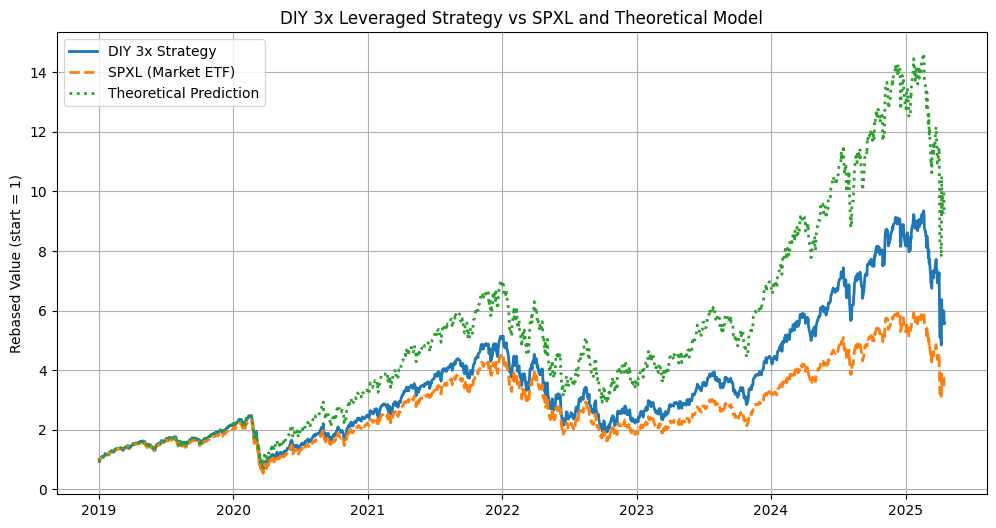

In [31]:
# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['DIY_3x'], label='DIY 3x Strategy', linewidth=2)
plt.plot(df.index, df['SPXL_rebased'], label='SPXL (Market ETF)', linewidth=2, linestyle='--')
plt.plot(df.index, df['predict_SPXL'], label='Theoretical Prediction', linewidth=2, linestyle=':')
plt.title("DIY 3x Leveraged Strategy vs SPXL and Theoretical Model")
plt.ylabel("Rebased Value (start = 1)")
plt.legend()
plt.grid(True)
plt.show()


### 📝 Comments on Question 10

The homemade 3× strategy, implemented via daily rebalancing on SPY, closely tracks the **theoretical model**, particularly in calm periods. It clearly diverges from **SPXL**, which is affected by:

- **Management fees**
- **Tracking error**
- **Real-world rebalancing imperfections**

The gap confirms that SPXL underperforms the ideal leveraged strategy — especially during volatile periods — due to **gamma decay** and **compounding effects**.

This suggests that, in theory, a bank could replicate leveraged exposure more efficiently in-house — provided transaction costs and operational constraints are manageable.

> However, implementing and managing such a strategy would require **robust systems** and **continuous rebalancing**, making it unfit for small investors but feasible for institutional desks.


### ✅ Advantages and Limitations of DIY Leveraged Strategy vs. SPXL

#### ✔️ Advantages of the DIY 3x strategy:

- **Better tracking**: The DIY strategy more closely follows the theoretical expected value (no fees, pure daily leverage logic).
- **Full control**: You avoid management fees, swap costs, and fund-level tracking errors.
- **Transparency**: All rebalancing and exposures are under your own control.

#### ❌ Limitations of the DIY 3x strategy:

- **Requires infrastructure**: You must implement daily rebalancing accurately — this demands automation, monitoring, and execution capability.
- **Transaction costs**: Real-world trading introduces bid-ask spreads and fees that aren’t in the simulation.
- **Margin and financing**: Leveraging 3× daily requires margin financing or derivative usage, which introduces risk and cost.
- **Operational complexity**: Scaling this for


## 🧾 Executive Summary

### 1. What should be told to clients to better manage their expectations?

Clients should be clearly informed that **leveraged ETFs such as SPXL and SPXS are designed for short-term tactical trading**, not long-term investment. Their behavior does not scale linearly with the underlying index due to **daily rebalancing and compounding effects**.

In particular:
- Over multiple days, **the return of a 3x leveraged ETF is *not* simply three times the return of the S&P 500**.
- **Volatility decay** can lead to underperformance over time, especially in sideways or choppy markets.
- The **prediction formula** shows that expected value depends on both the **performance of the index** and the **realized variance**, making it unsuitable for passive buy-and-hold strategies.

To manage expectations, clients should be told:

> “Leveraged ETFs amplify not only returns but also risks — and their performance depends not only on the index’s direction but also on its volatility. These products are best used with clear short-term views and regular monitoring.”

---

### 2. Should the team keep these products on the advisory list?

We recommend a **measured approach**:

- ✅ **Yes — but with strict framing and usage guidelines.**
- ❌ **No — for unsophisticated or long-term investors.**

**Justification**:
- Our analysis shows that **naïve expectations (3× performance) are misleading**. Over longer horizons, the predictive model performs better but still requires understanding of volatility effects.
- These products **can serve a purpose for informed, tactical investors** — especially with strong conviction in short-term market direction.
- However, **the performance divergence vs. expectations is significant**, and **misuse can lead to significant losses**, especially in volatile or mean-reverting markets.

**Policy suggestion**:
- Keep SPXL/SPXS **on a restricted list**, available **only upon request** or **for discretionary/advisory mandates**, with **disclaimers and documentation** on compounding risks.
- Provide clients with **risk/return simulation tools or education** to illustrate how returns behave under different market paths.


---

## ✅ Conclusion

This project has provided a comprehensive evaluation of leveraged ETFs (SPXL/SPXS) and **their behavior compared to client expectations and theoretical predictions**. Our findings reveal the importance of volatility, compounding effects, and proper usage framing when it comes to such products.

By combining empirical analysis, theoretical modeling, and client-oriented insights, we recommend keeping these instruments on the advisory list under strict conditions and with proper education.

This concludes the analysis.
